In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller # Importa a função do teste ADF


# --- Funções de Carregamento e Análise ---

def find_learning_curves(root_folder):
    """Busca recursivamente por arquivos 'learning_process.txt'."""
    filepaths = []
    for dirpath, _, filenames in os.walk(root_folder):
        if 'learning_process.txt' in filenames:
            filepaths.append(os.path.join(dirpath, 'learning_process.txt'))
    return filepaths

def find_stabilization_point_adf(curve, min_segment_len=100, significance_level=0.05):
    """
    Encontra o ponto de estabilização usando o Teste Aumentado de Dickey-Fuller (ADF).

    A função testa segmentos do final da curva, "andando para trás" no tempo,
    para encontrar o ponto mais antigo a partir do qual a série se torna estacionária.

    Args:
        curve (np.ndarray): A curva de aprendizado (não precisa ser suavizada).
        min_segment_len (int): O tamanho mínimo do segmento final a ser testado.
        significance_level (float): O p-valor limite para rejeitar a não-estacionariedade.

    Returns:
        int: O índice (episódio) onde a curva é considerada estável.
    """
    if len(curve) < min_segment_len:
        # Se a curva for muito curta, não é possível fazer o teste.
        # Retorna um ponto de estabilização padrão (metade da curva).
        return len(curve) // 2

    # Itera "de trás para frente" no tempo, começando com o segmento final da curva
    # e aumentando seu tamanho a cada passo.
    for i in range(len(curve) - min_segment_len, 0, -1):
        segment = curve[i:]
        
        # Realiza o Teste Aumentado de Dickey-Fuller no segmento
        # H₀ (hipótese nula): a série NÃO é estacionária (possui raiz unitária)
        # H₁ (hipótese alternativa): a série É estacionária
        result = adfuller(segment)
        p_value = result[1]
        
        # Se o p-valor for menor que o nível de significância, rejeitamos H₀.
        # Isso significa que o segmento é estatisticamente estacionário.
        if p_value < significance_level:
            # Encontramos o ponto mais antigo (o 'i' atual) onde a série restante é estável.
            return i
            
    # Se nenhum segmento do final da curva for considerado estacionário (caso raro),
    # retorna um ponto de estabilização padrão (início do último terço).
    print("Aviso: Não foi encontrado um ponto de estacionariedade claro. Usando valor padrão.")
    return len(curve) * 2 // 3

def get_decorrelation_time(series, alpha=0.05):
    """
    Calcula o tempo de decorrelação usando a Autocorrelation Function (ACF).

    Args:
        series (np.ndarray): A série temporal (a parte estável da curva).
        alpha (float): O nível de significância para o intervalo de confiança.

    Returns:
        int: O primeiro lag onde a ACF cruza o limite de significância.
    """
    from statsmodels.tsa.stattools import acf

    # Calcula a ACF e o intervalo de confiança
    autocorr, confint = acf(series, nlags=len(series)//4, alpha=alpha, fft=True)
    
    # Limite superior do intervalo de confiança (não precisamos do inferior)
    upper_conf_bound = confint[:, 1] - autocorr

    # Encontra o primeiro lag onde a autocorrelação é menor que o limite
    try:
        # Começa a busca a partir do lag 1 (a correlação no lag 0 é sempre 1)
        decorr_time = np.where(autocorr[1:] < upper_conf_bound[1:])[0][0] + 1
        return decorr_time
    except IndexError:
        # Se a série for muito curta ou muito correlacionada, retorna um valor padrão
        return max(5, len(series) // 10)

In [2]:
os.listdir('../data/models')

['.ipynb_checkpoints',
 'baseline_periodic_P=100',
 'novo_colision_slide_k=2_R=0_P=20',
 'novo_colision_slide_k=1_R=0_P=50',
 'baseline_periodic_P=20',
 'novo_colision_slide_k=2_R=0_P=50',
 'novo_colision_slide_k=1_R=0_P=20',
 'baseline_slide_P=50',
 'baseline_periodic_P=50',
 'baseline_slide_P=20',
 'novo_colision_slide_k=0_R=0_P=20',
 'del model.ipynb',
 'novo_colision_slide_k=0_R=0_P=50',
 'baseline_slide_P=100']

Analisando 8 curvas de aprendizado...

--- Processando Modelo 1 ---
  - Curva se torna estacionária por volta do episódio: 980
  - Tempo de decorrelação estimado: 1 episódios
  - Selecionados 20 pontos descorrelacionados deste modelo.



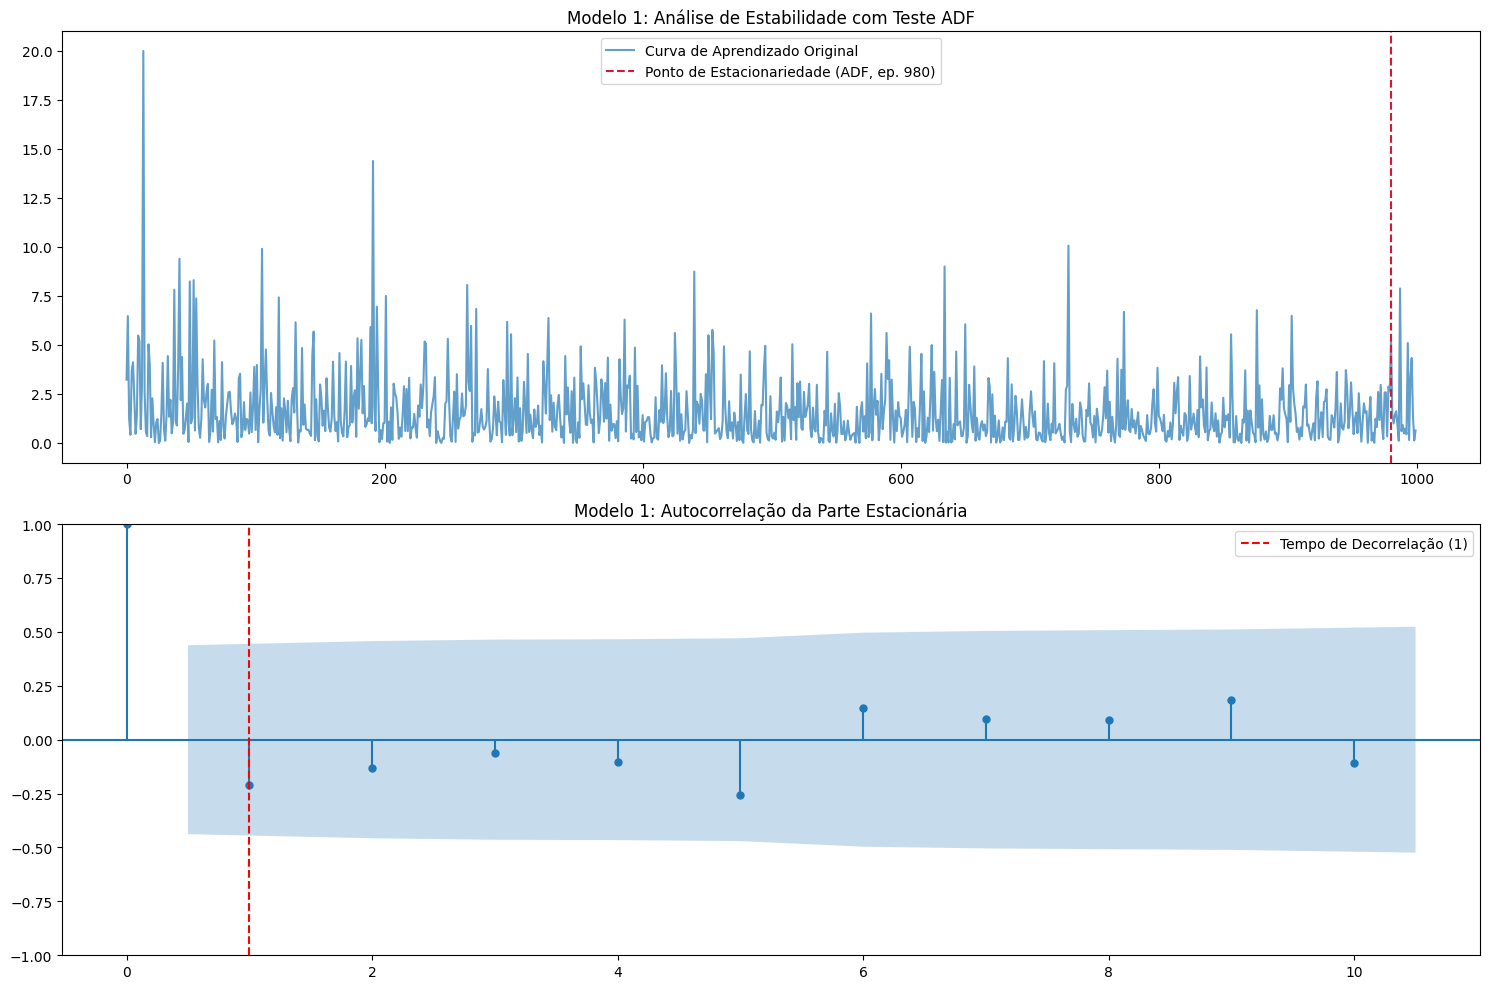

--- Processando Modelo 2 ---
  - Curva se torna estacionária por volta do episódio: 975
  - Tempo de decorrelação estimado: 1 episódios
  - Selecionados 25 pontos descorrelacionados deste modelo.



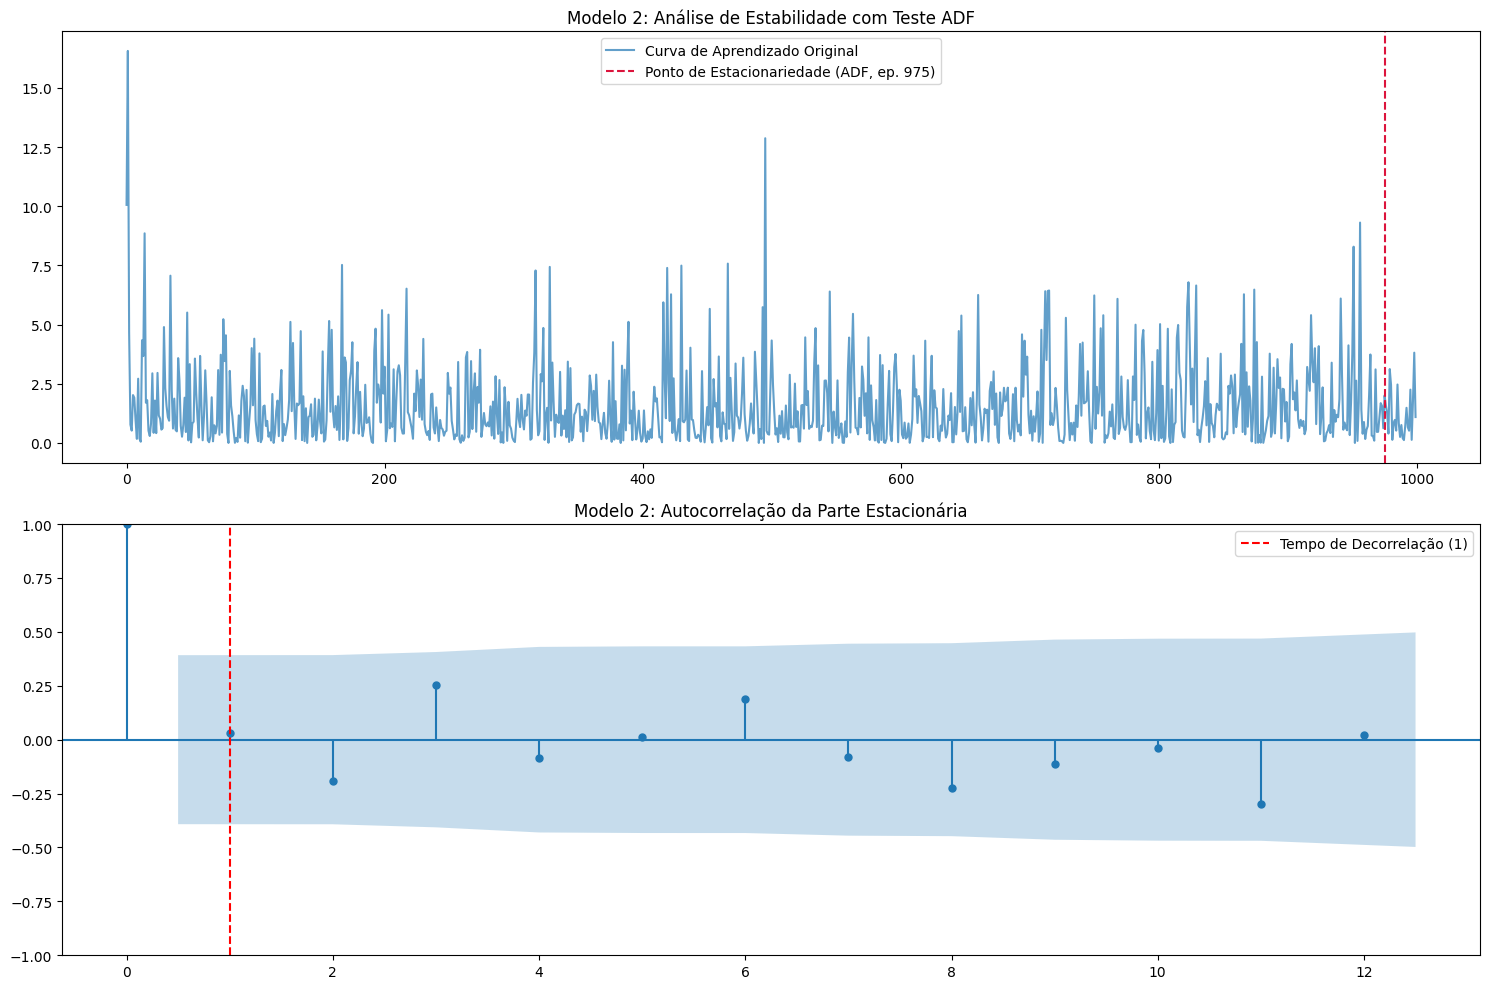

--- Processando Modelo 3 ---
  - Curva se torna estacionária por volta do episódio: 977
  - Tempo de decorrelação estimado: 1 episódios
  - Selecionados 23 pontos descorrelacionados deste modelo.

--- Processando Modelo 4 ---
  - Curva se torna estacionária por volta do episódio: 980
  - Tempo de decorrelação estimado: 1 episódios
  - Selecionados 20 pontos descorrelacionados deste modelo.

--- Processando Modelo 5 ---
  - Curva se torna estacionária por volta do episódio: 979
  - Tempo de decorrelação estimado: 1 episódios
  - Selecionados 21 pontos descorrelacionados deste modelo.

--- Processando Modelo 6 ---
  - Curva se torna estacionária por volta do episódio: 980
  - Tempo de decorrelação estimado: 1 episódios
  - Selecionados 20 pontos descorrelacionados deste modelo.

--- Processando Modelo 7 ---
  - Curva se torna estacionária por volta do episódio: 963
  - Tempo de decorrelação estimado: 1 episódios
  - Selecionados 37 pontos descorrelacionados deste modelo.

--- Processando

In [83]:
# --- CÉLULA DE EXECUÇÃO E PLOTAGEM INDIVIDUAL ---

# 1. ESPECIFIQUE A PASTA DOS MODELOS
folder_to_analyze = "../data/models/novo_colision_slide_k=0_R=0_P=20"

# 2. EXECUÇÃO DA ANÁLISE
filepaths = find_learning_curves(folder_to_analyze)

if not filepaths:
    print(f"ERRO: Nenhum arquivo 'learning_process.txt' encontrado em '{folder_to_analyze}'")
else:
    print(f"Analisando {len(filepaths)} curvas de aprendizado...\n")
    
    all_decorrelated_points = []
    
    for i, fpath in enumerate(filepaths):
        print(f"--- Processando Modelo {i+1} ---")
        curve_data = np.loadtxt(fpath, delimiter=',')

        # Etapa 1: Encontrar o ponto de estabilização com o TESTE ADF
        # A função antiga foi substituída pela nova 'find_stabilization_point_adf'
        stabilization_idx = find_stabilization_point_adf(curve_data, min_segment_len=20)
        print(f"  - Curva se torna estacionária por volta do episódio: {stabilization_idx}")
        
        stable_part = curve_data[stabilization_idx:]
        
        if len(stable_part) < 20:
            print("  - Parte estável muito curta para análise. Pulando.\n")
            continue
            
        # Etapa 2: Calcular o tempo de decorrelação
        decorr_time = get_decorrelation_time(stable_part)
        print(f"  - Tempo de decorrelação estimado: {decorr_time} episódios")
        
        # Etapa 3: Selecionar os pontos descorrelacionados
        decorrelated_samples = stable_part[::decorr_time]
        all_decorrelated_points.extend(decorrelated_samples)
        print(f"  - Selecionados {len(decorrelated_samples)} pontos descorrelacionados deste modelo.\n")

        # Plotagem opcional para os 2 primeiros modelos
        if i < 2:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
            
            ax1.plot(curve_data, label='Curva de Aprendizado Original', alpha=0.7)
            ax1.axvline(stabilization_idx, color='crimson', linestyle='--', label=f'Ponto de Estacionariedade (ADF, ep. {stabilization_idx})')
            ax1.set_title(f'Modelo {i+1}: Análise de Estabilidade com Teste ADF')
            ax1.legend()
            
            plot_acf(stable_part, ax=ax2, title=f'Modelo {i+1}: Autocorrelação da Parte Estacionária')
            ax2.axvline(decorr_time, color='red', linestyle='--', label=f'Tempo de Decorrelação ({decorr_time})')
            ax2.legend()
            
            plt.tight_layout()
            plt.show()

    # --- CÉLULA DE AGREGAÇÃO FINAL (permanece a mesma) ---

    if all_decorrelated_points:
        final_mean = np.mean(all_decorrelated_points)
        final_std = np.std(all_decorrelated_points)
        num_samples = len(all_decorrelated_points)
        
        print("\n" + "="*50)
        print("           Resultado Final da Análise Agregada")
        print("="*50)
        print(f"Total de pontos descorrelacionados de todos os modelos: {num_samples}")
        print(f"Média Final do Desempenho Estacionário: {final_mean:.4f}")
        print(f"Desvio Padrão do Desempenho Estacionário: {final_std:.4f}")
        print("\nSignificado:")
        print("Após o aprendizado se estabilizar (platô estacionário), o desempenho médio real do agente,")
        print(f"considerando apenas pontos estatisticamente independentes, é de {final_mean:.2%}")
        print("do tempo máximo de um 'trial' para encontrar o alvo.")
    else:
        print("\nNenhum ponto descorrelacionado foi coletado para a análise final.")